# Анализ перспективности отрасли жилищного и нежилого строительства

---

## 1. Подготовка и предварительная обработка данных

В рамках предварительного этапа исследования проведена фильтрация и оптимизация исходного реестра Федеральной налоговой службы (ФНС) для выделения целевого сегмента рынка.

* **Оптимизация объема:** в результате фильтрации количество записей сокращено с **600 000** до **100 000 строк**. Из выборки исключены нерелевантные типы субъектов, а также компании, чей основной вид деятельности не соответствует коду **ОКВЭД 41.20** (*Строительство жилых и нежилых зданий*).
* **Сокращение размерности:** из исходного файла `Реестр.xlsx` удалены избыточные признаки. В финальном структурированном датасете сохранены только ключевые идентификаторы и географические метрики:
    * `№ п/п`
    * `Тип субъекта`
    * `ИНН`
    * `ОГРН`
    * `Основной вид деятельности`
    * `Регион`
    * `Город`

Преобразованный массив данных, подготовленный для последующего парсинга финансовых показателей (EBIT) через API БФО ФНС (`bo.nalog.ru`), сохранен в файл **`regester.xlsx`**.


In [98]:
import pandas as pd

df = pd.read_excel("register.xlsx")

#needed_columns = ['№ п/п', 'Тип субъекта', 'ИНН', 'ОГРН', 'Основной вид деятельности', 'Регион', 'Город']

df_filtered = df[
    df["Основной вид деятельности"]
    .astype("string")
    .isin(["41.20 Строительство жилых и нежилых зданий",
           "41.2 Строительство жилых и нежилых зданий"
          ])
]

print(df.head())




   № п/п      Тип субъекта           ОГРН         ИНН  \
0      1  Юридическое лицо  1027800523376  7801190028   
1      2  Юридическое лицо  1037800033545  7801227976   
2      3  Юридическое лицо  1025204418293  5263039399   
3      4  Юридическое лицо  1025204411682  5263025484   
4      5  Юридическое лицо  1037800039276  7801123215   

                    Основной вид деятельности                      Регион  \
0   41.2 Строительство жилых и нежилых зданий      78 - г.Санкт-Петербург   
1  41.20 Строительство жилых и нежилых зданий      78 - г.Санкт-Петербург   
2  41.20 Строительство жилых и нежилых зданий  52 - Нижегородская область   
3  41.20 Строительство жилых и нежилых зданий  52 - Нижегородская область   
4  41.20 Строительство жилых и нежилых зданий      78 - г.Санкт-Петербург   

               Город  
0                NaN  
1                NaN  
2  г Нижний Новгород  
3  г Нижний Новгород  
4                NaN  


## 2. Сбор финансовых данных через API БФО (ФНС)

Для расчета метрики **EBIT** и оценки инвестиционной привлекательности отрасли выполнен сбор актуальной финансовой отчетностью компаний. 

**Идентификаторы:** Поиск и сопоставление отчетности в API осуществлялись по уникальным номерам **ИНН** организаций, отобранных на предыдущем шаге.

---
### Скрипт сбора данных:


In [125]:
import requests
import pandas as pd
import time
import os
from tqdm.notebook import tqdm


session = requests.Session()

session.headers.update({
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
})

venture_data = []

search_url = "https://bo.nalog.gov.ru/advanced-search/organizations/search"


# ==========================================
# ОБРАБАТЫВАЕМ ИНН
# ==========================================

#df_filtered = df_filtered.reset_index(drop=True)
print(f"Исходные размеры: {df_filtered.shape}")

df_sample = df_filtered.sample(n=50000).reset_index(drop=True)
print(f"Выборочные размеры: {df_sample.shape}")

#for index, row in df_filtered.iterrows():
for index, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Парсинг ФНС"):

    inn = str(row["ИНН"]).strip()

    if index%1000 == 0:
        print(f"Обрабатываю ИНН: {inn} ({index}/{len(df_sample)})")

    try:

        # ==========================================
        # 1. ПОИСК ОРГАНИЗАЦИИ
        # ==========================================

        params = {
            "query": inn,
            "page": 0
        }

        response = session.get(
            search_url,
            params=params,
            timeout=10
        )

        response.raise_for_status()

        search_data = response.json()

        if not search_data.get("content"):
            continue

        org_id = search_data["content"][0]["id"]


        # ==========================================
        # 2. ПОЛУЧАЕМ БФО
        # ==========================================

        bfo_url = f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo/"

        bfo_response = session.get(
            bfo_url,
            timeout=10
        )

        bfo_response.raise_for_status()

        bfo_data = bfo_response.json()


        # ==========================================
        # 3. РАССЧИТЫВАЕМ EBITA
        # ==========================================

        for report in bfo_data:

            year = int(report.get("period"))

            corrections = report.get("typeCorrections", [])

            for correction_data in corrections:

                correction = correction_data.get("correction", {})

                financial_result = correction.get(
                    "financialResult",
                    {}
                )

                row_2400 = financial_result.get("current2400")
                row_2410 = financial_result.get("current2410", 0) or 0
                row_2330 = financial_result.get("current2330", 0) or 0
                row_2110 = financial_result.get("current2110")#revenue

                if row_2400 is not None:
                    ebit = (
                        row_2400
                        + abs(row_2410)
                        + abs(row_2330)
                    )
                else:
                    ebit = None

                if ebit is not None and row_2110 not in (None, 0):
                    ebit_margin = (ebit / row_2110) * 100
                else:
                    ebit_margin = None

                venture_data.append({
                    "ИНН": inn,
                    "Год": year,
                    "Чистая прибыль (убыток)": row_2400,
                    "EBIT": ebit,
                    "EBIT_margin": ebit_margin
                })


    # ==========================================
    # ОБРАБОТКА ОШИБОК
    # ==========================================

    except Exception as e:

        print(f"Ошибка при обработке ИНН {inn}: {e}")

    time.sleep(0.5)


# ==========================================
# 4. СОЗДАЁМ DATAFRAME
# ==========================================

df_venture = pd.DataFrame(venture_data)

print("\nПарсинг завершён!")

Исходные размеры: (97580, 7)
Выборочные размеры: (50000, 7)


Парсинг ФНС:   0%|          | 0/50000 [00:00<?, ?it/s]

Обрабатываю ИНН: 661107892350 (0/50000)
Обрабатываю ИНН: 230409668899 (1000/50000)
Обрабатываю ИНН: 352831504113 (2000/50000)
Обрабатываю ИНН: 772970742623 (3000/50000)
Обрабатываю ИНН: 524707991864 (4000/50000)
Обрабатываю ИНН: 631300837245 (5000/50000)
Обрабатываю ИНН: 245512666241 (6000/50000)
Обрабатываю ИНН: 590773936415 (7000/50000)
Обрабатываю ИНН: 682907551949 (8000/50000)
Обрабатываю ИНН: 711505052791 (9000/50000)
Обрабатываю ИНН: 232906593767 (10000/50000)
Обрабатываю ИНН: 31100521664 (11000/50000)
Обрабатываю ИНН: 667012928658 (12000/50000)
Обрабатываю ИНН: 7809020444 (13000/50000)
Обрабатываю ИНН: 360302843356 (14000/50000)
Обрабатываю ИНН: 614058112939 (15000/50000)
Обрабатываю ИНН: 590616967149 (16000/50000)
Обрабатываю ИНН: 361500746042 (17000/50000)
Обрабатываю ИНН: 230810983811 (18000/50000)
Обрабатываю ИНН: 236500500462 (19000/50000)
Обрабатываю ИНН: 616507916700 (20000/50000)
Обрабатываю ИНН: 616513055707 (21000/50000)
Обрабатываю ИНН: 771779137734 (22000/50000)
Обра

## 3. Трансформация и структурирование данных

Для проведения корректного финансового анализа и оценки динамики по годам выполнено переформатирование датасета. Исходная «длинная» структура таблицы преобразована в «широкий» (матричный) вид, где для каждого контрагента сформированы временные ряды показателей.

На данном этапе сформированы три профильные аналитические матрицы:
1. **Матрица EBIT:** абсолютные значения операционной прибыли компаний по годам.
2. **Матрица EBIT margin:** относительные показатели рентабельности операционной прибыли.
3. **Матрица Чистой прибыли:** итоговый финансовый результат (чистая прибыль / убыток) организаций.



In [126]:
print(df_venture.shape)
print(df_venture.head(10))

(4935, 5)
          ИНН   Год  Чистая прибыль (убыток)   EBIT  EBIT_margin
0  6604027077  2025                    352.0  405.0     4.304389
1  6604027077  2024                      NaN    NaN          NaN
2  6604027077  2022                      0.0    0.0     0.000000
3  6604027077  2021                      0.0    0.0     0.000000
4  6604027077  2023                      0.0    0.0     0.000000
5  3334002274  2024                     78.0  100.0     4.599816
6  3334002274  2022                   -270.0 -255.0   -18.097942
7  3334002274  2021                    235.0  261.0    19.247788
8  3334002274  2025                    105.0  130.0     5.271695
9  2543056458  2025                      NaN    NaN          NaN


In [127]:
# Поворачиваем таблицу: ИНН оставляем в строках, Года переносим в столбцы, а внутри будут значения EBITA
df_pivot1 = df_venture.pivot(index='ИНН', columns='Год', values='EBIT')

# Превращаем индекс 'ИНН' обратно в обычный столбец, чтобы таблица выглядела стандартно
df_pivot1 = df_pivot1.reset_index()

print(f"Таблица успешно переформатирована. Всего уникальных ИНН: {len(df_pivot1)}")
print(df_pivot1)

df_pivot2 = df_venture.pivot(index='ИНН', columns='Год', values='EBIT_margin').reset_index()

df_pivot3 = df_venture.pivot(index='ИНН', columns='Год', values='Чистая прибыль (убыток)').reset_index()


Таблица успешно переформатирована. Всего уникальных ИНН: 1308
Год          ИНН      2021      2022       2023       2024       2025
0     1001010821  555345.0  738730.0  1103053.0  1205806.0  1001561.0
1     1001017312       NaN       NaN        NaN        NaN        NaN
2     1001049530       NaN       NaN        NaN        NaN        NaN
3     1001049547       NaN       NaN        NaN        NaN        NaN
4     1001068807    -666.0       0.0      886.0        0.0        NaN
...          ...       ...       ...        ...        ...        ...
1303  9728049939       NaN  107063.0  -124668.0        NaN -1056544.0
1304  9728057993       NaN     -21.0        0.0     9353.0    12147.0
1305  9728064831       NaN     -39.0        0.0      -22.0    -3097.0
1306  9728078714       NaN       NaN       98.0        NaN        NaN
1307  9729080177     -59.0     -61.0        NaN        NaN        NaN

[1308 rows x 6 columns]


## 4. Визуализация распределения финансовых показателей

Для оценки структуры отрасли, выявления центральных тенденций и анализа вариативности показателей применяется визуализация с помощью **диаграмм размаха (Boxplot)**. 

### Методологические особенности графиков:
* **Исключение выбросов (`showfliers=False`):** в строительном секторе присутствуют сверхкрупные игроки и компании с экстремальными убытками. Чтобы они не искажали общую визуализацию и масштаб, графики построены в пределах межквартильного размаха (IQR).
* **Динамический анализ:** для каждого года (с 2021 по 2025 гг.) данные очищаются от пропусков индивидуально, что обеспечивает максимальную репрезентативность выборок.

---
### Скрипт построения графиков:


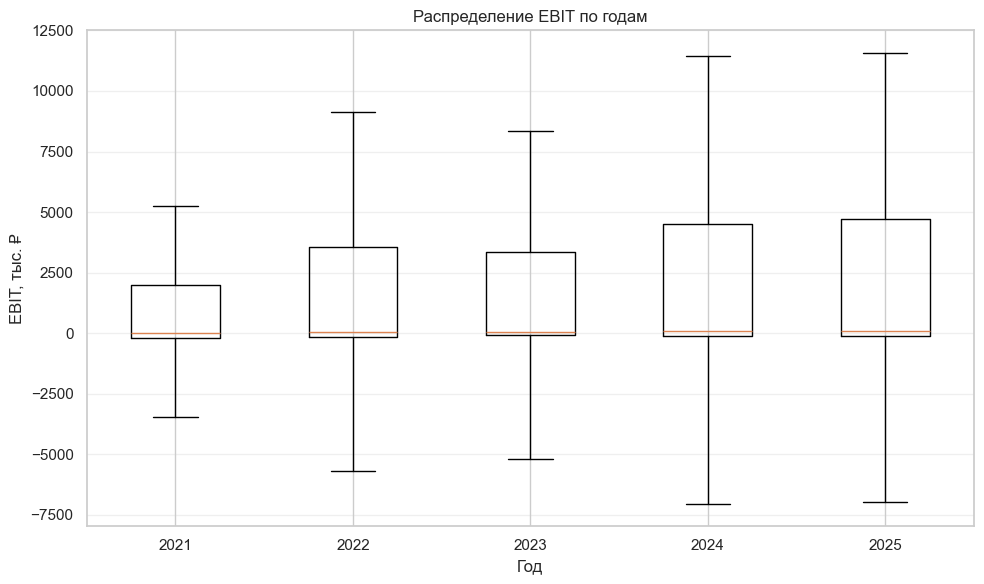

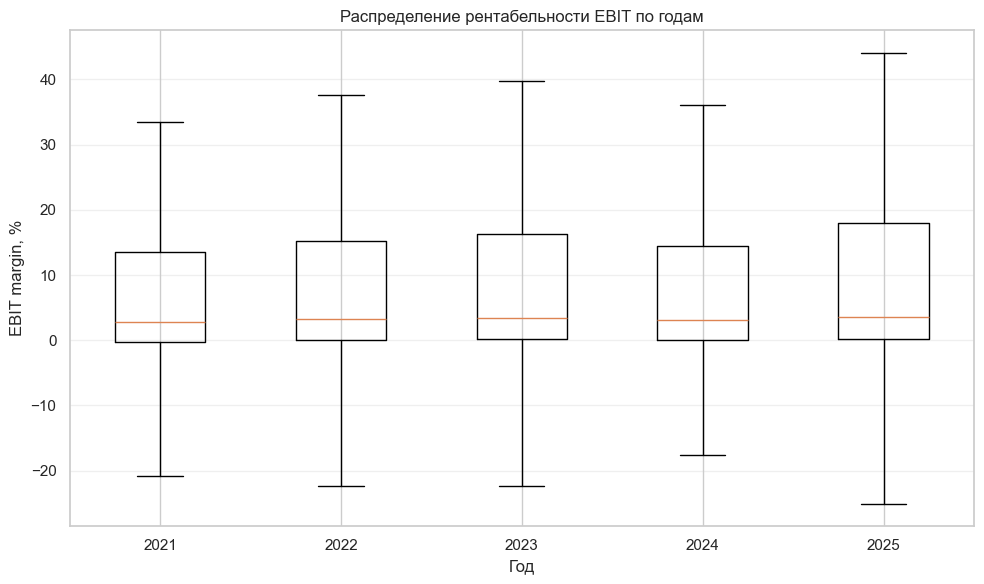

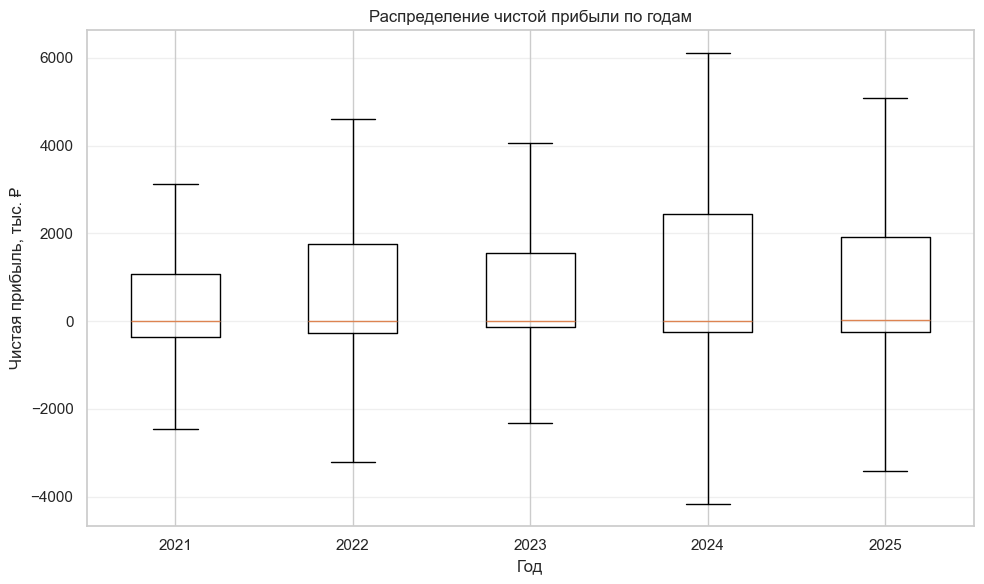

In [128]:
import pandas as pd
import matplotlib.pyplot as plt

years = [2021, 2022, 2023, 2024, 2025]


def plot_boxplot(df, value_name, title, ylabel, scale=1):
    data = df[["ИНН"] + years].copy()

    for year in years:
        data[year] = pd.to_numeric(data[year], errors="coerce") / scale

    # Убираем пропуски отдельно для каждого года
    box_data = [
        data[year].dropna().values
        for year in years
    ]

    plt.figure(figsize=(10, 6))

    plt.boxplot(
        box_data,
        tick_labels=years,
        showfliers=False
    )

    plt.title(title)
    plt.xlabel("Год")
    plt.ylabel(ylabel)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


# 1. EBITA
plot_boxplot(
    df_pivot1,
    value_name="EBIT",
    title="Распределение EBIT по годам",
    ylabel="EBIT, тыс. ₽",
    scale=1
)

# 2. Рентабельность EBITA
plot_boxplot(
    df_pivot2,
    value_name="EBIT_margin",
    title="Распределение рентабельности EBIT по годам",
    ylabel="EBIT margin, %",
    scale=1
)

# 3. Чистая прибыль
plot_boxplot(
    df_pivot3,
    value_name="Чистая прибыль (убыток)",
    title="Распределение чистой прибыли по годам",
    ylabel="Чистая прибыль, тыс. ₽",
    scale=1
)

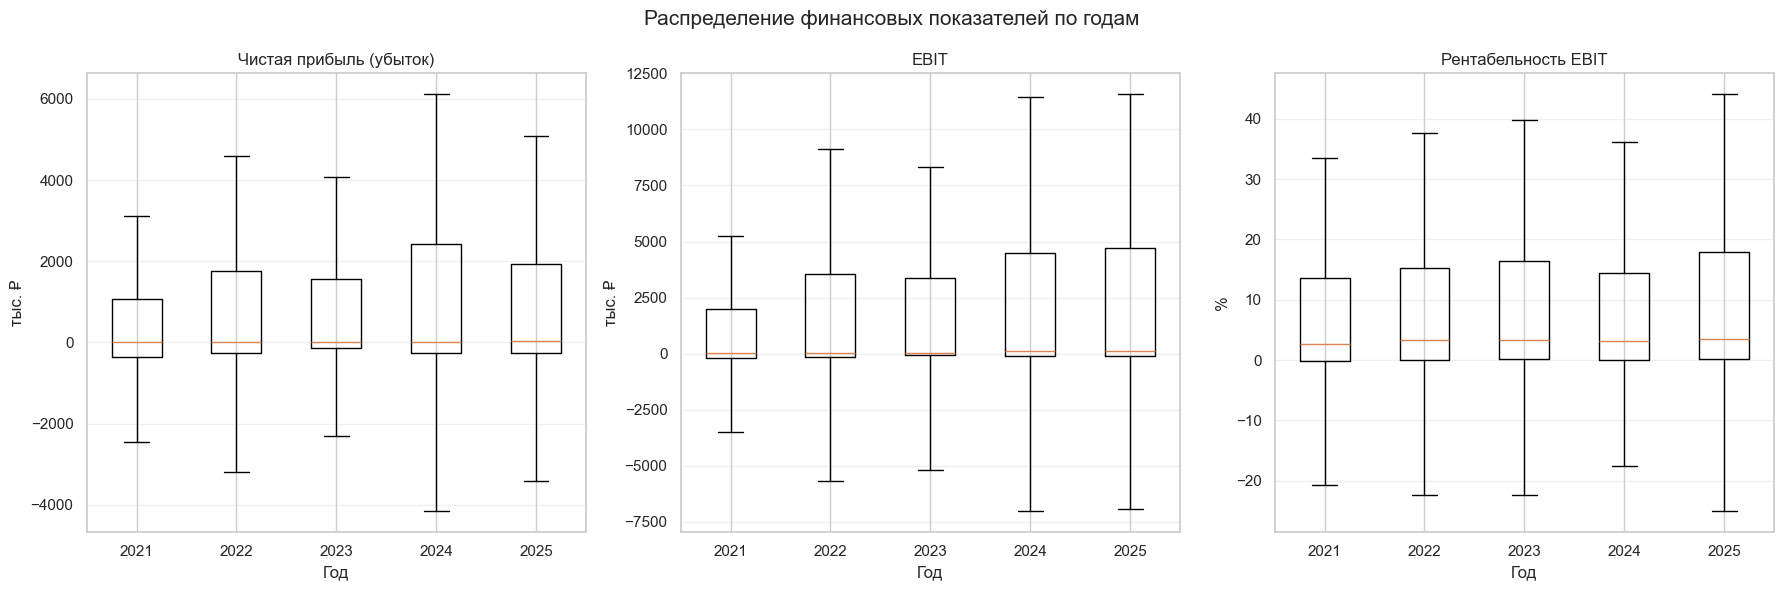

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

years = [2021, 2022, 2023, 2024, 2025]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6)
)


def add_boxplot(ax, df, title, ylabel, scale=1):
    data = df[years].copy()

    for year in years:
        data[year] = pd.to_numeric(
            data[year], errors="coerce"
        ) / scale

    box_data = [
        data[year].dropna().values
        for year in years
    ]

    ax.boxplot(
        box_data,
        tick_labels=years,
        showfliers=False
    )

    ax.set_title(title)
    ax.set_xlabel("Год")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)


add_boxplot(
    axes[0],
    df_pivot3,
    "Чистая прибыль (убыток)",
    "тыс. ₽",
    scale=1
)

add_boxplot(
    axes[1],
    df_pivot1,
    "EBIT",
    "тыс. ₽",
    scale=1
)

add_boxplot(
    axes[2],
    df_pivot2,
    "Рентабельность EBIT",
    "%",
    scale=1
)

#axes[0].sharey(axes[1])

fig.suptitle(
    "Распределение финансовых показателей по годам",
    fontsize=15
)

plt.tight_layout()
plt.show()

## 5. Аналитическое заключение и оценка перспективности отрасли

На основе проведенного анализа финансовых показателей выборки компаний из сегмента **ОКВЭД 41.20 (Строительство жилых и нежилых зданий)** за период 2021–2025 гг. сформированы следующие ключевые выводы.

### 1. Перспективность и общее состояние отрасли
* Для половины участников рынка операционная деятельность балансирует на грани безубыточности. 
* Несмотря на околонулевую медиану, верхние «усы» и границы третьих квартилей (верхние края ящиков) для EBIT и Чистой прибыли демонстрируют уверенную тенденцию к росту к 2024–2025 годам. Верхняя граница EBIT выросла с ~5 000 тыс. ₽ в 2021 году до ~11 500 тыс. ₽ к 2025 году. Это означает, что отрасль перспективна и высокодоходна для эффективных игроков, способных масштабировать бизнес и контролировать издержки.

### 2. Анализ операционной эффективности (EBIT Margin)
* Показатель `EBIT margin` демонстрирует наиболее устойчивую динамику. Медианное значение рентабельности стабильно удерживается в положительной зоне на уровне **~3–4%**.
* Межквартильный размах по рентабельности с каждым годом расширяется вверх: в 2025 году верхний «ус» достигает значений свыше **40%**. Отрасль предоставляет возможности для формирования высокой нормы прибыли, однако риски также нарастают.

### 3. Важные отраслевые особенности и риски
* Одновременно с ростом максимальных прибылей (верхние усы) наблюдается зеркальное увеличение потенциальных убытков (нижние усы). В 2024–2025 гг. глубина просадки по EBIT доходит до -7 000 тыс. ₽. Строительный сектор характеризуется повышенным уровнем финансового риска и чувствительностью к рыночной конъюнктуре.
* График Чистой прибыли в 2025 году показывает небольшое сжатие верхнего квартиля по сравнению с 2024 годом при сохранении высокого EBIT. Это может свидетельствовать о росте внереализационных расходов (например, стоимости обслуживания кредитов и проектного финансирования).



## 6. Расчет и фильтрация темпов роста чистой прибыли

Для выполнения задачи по анализу динамики прибыли выбран **4-летний горизонт (\(N = 4\))**, сопоставляющий базовый **2021 год** и отчетный **2025 год**. Это позволяет оценить среднесрочный тренд развития компаний строительного сектора.

### Логика предобработки и фильтрации:
* Расчет относительного изменения: темп роста рассчитывается как процентное отношение изменения чистой прибыли к модулю ее базового значения в 2021 году. Это позволяет корректно учитывать как прибыльные, так и убыточные на базовый период предприятия.
* Исключение аномальных значений (выбросов): из выборки удаляются компании с экстремальными скачками темпов роста (более **100%** по модулю в обе стороны). Такая фильтрация необходима, так как сверхвысокие проценты обычно вызваны эффектом «низкой базы» (например, ростом прибыли со 100 рублей до 1 миллиона) и искажают реальное распределение по отрасли.

In [170]:
df_growth = df_pivot3[["ИНН", 2021, 2025]].copy()

# Приводим к числовому типу
df_growth[2021] = pd.to_numeric(df_growth[2021], errors="coerce")
df_growth[2025] = pd.to_numeric(df_growth[2025], errors="coerce")

df_growth = df_growth.dropna(subset=[2021, 2025])

df_growth["Рост, %"] = np.where(
    df_growth[2021] != 0,
    ((df_growth[2025] - df_growth[2021]) / abs(df_growth[2021])) * 100,
    np.nan)

df_growth = df_growth.dropna(subset=["Рост, %"]).copy()
#df_growth["Рост, %"] = (df_growth["Рост, %"].round().astype(int))
df_growth = df_growth[df_growth["Рост, %"].abs() <= 100].copy()
growth_distribution = (df_growth["Рост, %"].value_counts().sort_index())

## 7. Визуализация распределения темпов роста (Интервальный анализ)

Для построения наглядного и информативного графика непрерывные значения процентного роста разбиты на 10-процентные интервалы в диапазоне от -100% до +100%. Это решает проблему избыточной детализации и позволяет сгруппировать компании по схожим паттернам развития.

Визуализация реализуется с помощью столбчатой диаграммы (`plt.bar`), где:
* Ось X: дискретные интервалы изменения чистой прибыли за 4 года (от критического падения до двукратного роста).
* Ось Y: абсолютное количество строительных компаний, попавших в соответствующий интервал.


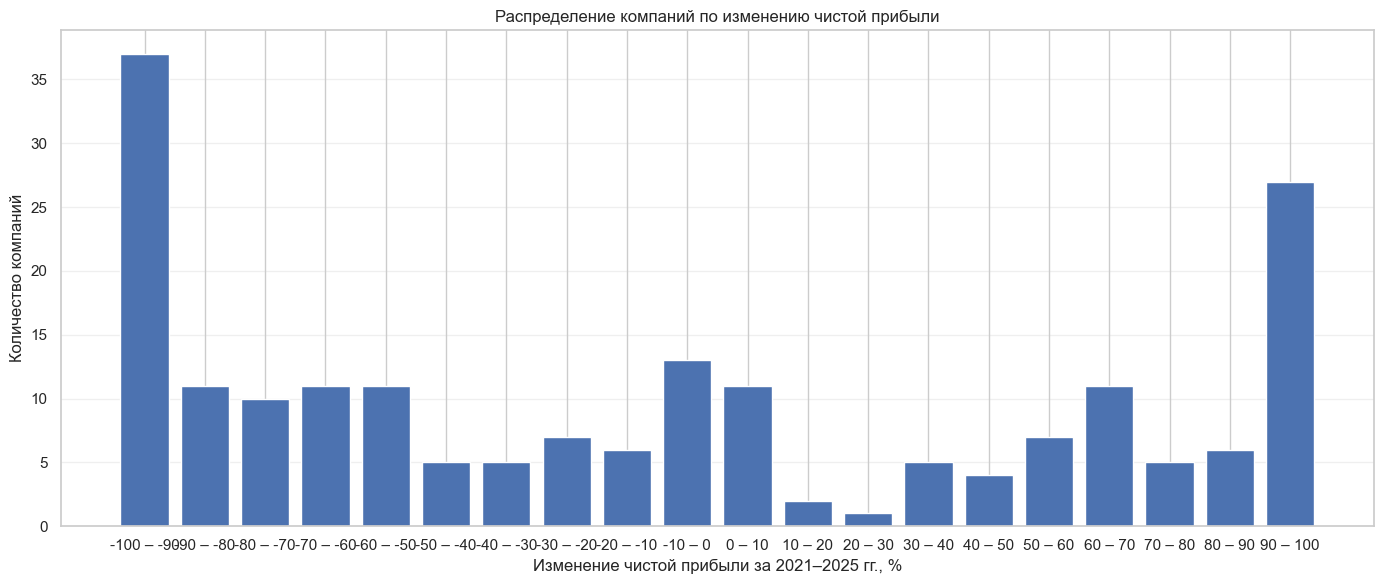

In [182]:
bins = np.arange(-100, 101, 10)

labels = [
    "-100 – -90",
    "-90 – -80",
    "-80 – -70",
    "-70 – -60",
    "-60 – -50",
    "-50 – -40",
    "-40 – -30",
    "-30 – -20",
    "-20 – -10",
    "-10 – 0",
    "0 – 10",
    "10 – 20",
    "20 – 30",
    "30 – 40",
    "40 – 50",
    "50 – 60",
    "60 – 70",
    "70 – 80",
    "80 – 90",
    "90 – 100"
]

growth_bins = pd.cut(
    df_growth["Рост, %"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

growth_distribution = growth_bins.value_counts().sort_index()

plt.figure(figsize=(14, 6))

plt.bar(
    growth_distribution.index,
    growth_distribution.values,
    width=0.8
)

plt.xlabel("Изменение чистой прибыли за 2021–2025 гг., %")
plt.ylabel("Количество компаний")
plt.title("Распределение компаний по изменению чистой прибыли")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 8. Анализ результатов и выводы по графику распределения:

Полученная гистограмма темпов роста чистой прибыли за 2021–2025 гг. выявляет критически важную структурную особенность строительного сектора (**ОКВЭД 41.20**):

1. **Ярко выраженная биполяризация (U-образное распределение):**
   Вместо классического колокола (нормального распределения) с пиком около нуля, график имеет два мощных экстремума на границах. Рынок жестко разделился на полярные группы:
   * Максимальное падение (`-100 – -90%`). Самый высокий столбец на графике (~37 компаний). Это организации, чья чистая прибыль за 4 года фактически обнулилась или сменилась критическими убытками.
   * Максимальный рост (`90 – 100%`). Второй по величине пик (~27 компаний). Сюда входят лидеры рынка, сумевшие практически удвоить свою чистую прибыль за анализируемый период.

2. **Вымывание «среднего класса»:**
   Центральная часть распределения (от -50% до +50%) выражена слабо, с локальным провалом в зоне умеренного роста (`10 – 30%`). В отрасли практически отсутствуют стабильные компании со средними, предсказуемыми темпами развития. Строительный бизнес функционирует в режиме крайностей.

3. **Отраслевой вывод:**
   Диаграмма подтверждает, что строительный сектор находится в фазе жесткой консолидации и передела рынка. Внешние макроэкономические факторы (изменение условий ипотечных программ, рост стоимости проектного финансирования и дефицит кадров) бьют по всем игрокам, но с разным результатом. Слабые компании стремительно теряют позиции и уходят в дефолтную зону, в то время как крупные или наиболее эффективные игроки аккумулируют освободившийся спрос и удваивают прибыль. 


## 9. Геопространственный анализ и картографирование финансовых результатов

Финальным этапом исследования является визуализация пространственного распределения строительных компаний на интерактивной карте России. Это позволяет выявить географические кластеры деловой активности и оценить, как регион присутствия влияет на успешность бизнеса.

* Координаты компаний определяются по полям широты (`lat`) и долготы (`lon`). Начальная точка карты центрирована на Урале для оптимального охвата европейской и азиатской частей страны.
* Применяется палитра `RdYlBu_r` с центрированием в нуле (`TwoSlopeNorm`). Компании с высокими убытками окрашиваются в красные оттенки, сбалансированные — в желтые, а высокоприбыльные лидеры — в синие.
* Радиус кругов масштабируется пропорционально корню от абсолютной прибыли. Это сглаживает экстремальные значения и наглядно выделяет масштаб бизнеса даже на фоне небольших организаций.

In [200]:
df_map = df_pivot3[["ИНН", 2025]].copy()

df_map = df_map.rename(
    columns={2025: "Чистая прибыль"}
)

df_cities = df_filtered[["ИНН", "Город"]].copy()
df_map["ИНН"] = df_map["ИНН"].astype(str).str.strip()
df_cities["ИНН"] = df_cities["ИНН"].astype(str).str.strip()

df_map = df_map.merge(
    df_cities,
    on="ИНН",
    how="left"
)

df_map = df_map.dropna(subset=["Чистая прибыль", "Город"]).copy()

cities = df_map["Город"].dropna().unique()

In [203]:
from geopy.geocoders import Nominatim
from time import sleep

geolocator = Nominatim(
    user_agent="company_profit_map"
)

city_coords = {}

for city in cities:
    try:
        location = geolocator.geocode(
            f"{city}, Россия"
        )
        
        if location:
            city_coords[city] = (
                location.latitude,
                location.longitude
            )
        else:
            city_coords[city] = (None, None)
            
    except Exception as e:
        print(f"Ошибка для {city}: {e}")
        city_coords[city] = (None, None)
    
    sleep(1)

In [204]:
city_coords

{'г Петрозаводск': (61.7995109, 34.3418868),
 'г Майкоп': (44.6103252, 40.0815399),
 'г Якутск': (62.0289037, 129.7161052),
 'г Владикавказ': (43.0276207, 44.6066077),
 'г Набережные Челны': (55.7302128, 52.3614124),
 'г Нижнекамск': (55.6181759, 51.8477743),
 'г Казань': (55.796951, 49.1273881),
 'г Новосибирск': (55.0410708, 82.9179369),
 'г Грозный': (43.3086383, 45.7065735),
 'г Цивильск': (55.8057394, 47.4440654),
 'г Чебоксары': (56.129909, 47.2719854),
 'г Барнаул': (53.3248455, 83.7945202),
 'г Геленджик': (44.5502587, 38.0687803),
 'г Краснодар': (45.0112333, 38.9845655),
 'г Сочи': (43.5987157, 39.7789083),
 'пгт. Сириус': (None, None),
 'ГОРОД ТИХОРЕЦК': (45.854679, 40.128124),
 'г Темрюк': (45.2280346, 37.4785437),
 'г Красноярск': (56.0232606, 92.8637399),
 'г Владивосток': (43.2155846, 131.950682),
 'г Ставрополь': (43.9054241, 42.7368409),
 'г Хабаровск': (48.528096, 135.1829132),
 'г Уфа': (51.8180208, 55.0225773),
 'г Благовещенск': (50.2529449, 127.5510035),
 'г Белог

In [208]:
df_map["lat"] = df_map["Город"].map(
    lambda x: city_coords.get(x, (None, None))[0]
)
df_map["lon"] = df_map["Город"].map(
    lambda x: city_coords.get(x, (None, None))[1]
)
df_map = df_map.dropna(subset=["lat", "lon"]).copy()
print(df_map[["Город", "lat", "lon"]])

               Город        lat         lon
0     г Петрозаводск  61.799511   34.341887
9           г Майкоп  44.610325   40.081540
23          г Якутск  62.028904  129.716105
31          г Якутск  62.028904  129.716105
43     г Владикавказ  43.027621   44.606608
...              ...        ...         ...
1226        г Сургут  61.284189   73.389309
1235      г Ноябрьск  63.119118   75.346704
1236    г Губкинский  64.433782   76.489809
1237      г Черкесск  44.203459   42.060187
1238    г Карачаевск  43.782761   41.911067

[177 rows x 3 columns]


In [219]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(
        df_map["lon"],
        df_map["lat"]
    ),
    crs="EPSG:4326"
)

In [220]:
gdf["Размер"] = gdf["Чистая прибыль"].abs()

In [227]:
import folium
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

max_profit = gdf["Чистая прибыль"].abs().max()

norm = mcolors.TwoSlopeNorm(
    vmin=-max_profit,
    vcenter=0,
    vmax=max_profit
)

cmap = plt.cm.RdYlBu_r

m = folium.Map(
    location=[56, 60],
    zoom_start=4,
    tiles="OpenStreetMap"
)

for _, row in gdf.iterrows():

    value = row["Чистая прибыль"]

    color = mcolors.to_hex(
        cmap(norm(value))
    )

    radius = 3 + 12 * np.sqrt(
        abs(value) / max_profit
    )

    folium.CircleMarker(
        location=[
            row["lat"],
            row["lon"]
        ],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        weight=1,

        tooltip=(
            f"<b>ИНН:</b> {row['ИНН']}<br>"
            f"<b>Город:</b> {row['Город']}<br>"
            f"<b>Чистая прибыль:</b> "
            f"{row["Чистая прибыль"]:,.1f} млн руб."
        )
    ).add_to(m)
m